In [4]:
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.models import resnet50, ResNet50_Weights
from tqdm import tqdm

# Config

# Let us use the cifar 10 dataset

embed_dim = 16
n_heads = 2
patch_size = 16
num_classes = 10
d_head = embed_dim // n_heads
device = "cuda" if torch.cuda.is_available() else "cpu"

# DataLoading part
tf = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
train_full = datasets.CIFAR10("./data", train=True,  download=True, transform=tf)
test_full  = datasets.CIFAR10("./data", train=False, download=True, transform=tf)
train_ds = Subset(train_full, range(5000))     # small subset, rudimentary results
test_ds  = Subset(test_full,  range(1000))
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=2)
test_dl  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=2)
# DataLoading part end

# Patch embed
patch_embed = nn.Conv2d(in_channels = 3, out_channels = embed_dim, kernel_size = patch_size, stride = patch_size, padding = "valid").to(device)

# cls + knowledge distillation tokens
cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim, device = device))
dist_token = nn.Parameter(torch.zeros(1, 1, embed_dim, device = device))

# positional embedding
pos_embed  = nn.Parameter(torch.zeros(1, 198, embed_dim, device=device))

nn.init.trunc_normal_(cls_token, std = 0.02) # random small initialization
nn.init.trunc_normal_(dist_token, std = 0.02)
nn.init.trunc_normal_(pos_embed, std = 0.02)

ln1 = nn.LayerNorm(embed_dim, eps = 1e-6).to(device)
w_q, w_k, w_v, w_o = [nn.Linear(embed_dim, embed_dim).to(device) for _ in range(4)]

# why are we saving it to device??

ln_pre_mlp = nn.LayerNorm(embed_dim).to(device)

mlp = nn.Sequential(
    nn.Linear(embed_dim, embed_dim*4),
    nn.GELU(),
    nn.Linear(embed_dim*4, embed_dim)
).to(device)

final_ln = nn.LayerNorm(embed_dim, eps = 1e-6).to(device)
cls_head = nn.Linear(embed_dim, num_classes).to(device)
dist_head = nn.Linear(embed_dim, num_classes).to(device)

# Now move on to collecting all the parameters

layers = [patch_embed, ln1, w_q, w_k, w_v, w_o, ln_pre_mlp, mlp, final_ln, cls_head, dist_head]
params = [cls_token, dist_token, pos_embed] + [p for l in layers for p in l.parameters()]
opt = torch.optim.AdamW(params, lr=5e-4, weight_decay=0.05)

print(f"trainable params: {sum(p.numel() for p in params)}")

# Let us get the pretrained teacher CNN
teacher = resnet50(weights = ResNet50_Weights.IMAGENET1K_V2)
teacher.fc = nn.Linear(teacher.fc.in_features, num_classes)
teacher = teacher.to(device).eval()

for p in teacher.parameters(): p.requires_grad = False
for p in teacher.fc.parameters(): p.requires_grad = True

# Now let us get to our optimizer
opt_t = torch.optim.Adam(teacher.fc.parameters(), lr = 1e-3)

for xb, yb in train_dl: # 1 pass over the fc to beat noise
  xb, yb = xb.to(device), yb.to(device)
  opt_t.zero_grad()
  F.cross_entropy(teacher(xb), yb).backward()
  opt_t.step()

for p in teacher.fc.parameters(): p.requires_grad = False
print("Teacher head is fine-tuned and won't be updated.")

# Time to train; let's goo

for epoch in tqdm(range(10)):
    print(f"Epoch: {epoch}")
    training = True 
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)

        with torch.no_grad():                # CHANGED: no_grad wraps ONLY the teacher
            teacher_labels = teacher(xb).argmax(-1)

        patches = patch_embed(xb).flatten(2).permute(0, 2, 1)
        B = patches.shape[0]
        X = torch.cat((cls_token.expand(B, -1, -1),
                       dist_token.expand(B, -1, -1), patches), dim=1) + pos_embed

        B, G, _ = X.shape
        normed = ln1(X)
        Q = w_q(normed).reshape(B, G, n_heads, d_head).transpose(1, 2)
        K = w_k(normed).reshape(B, G, n_heads, d_head).transpose(1, 2)
        V = w_v(normed).reshape(B, G, n_heads, d_head).transpose(1, 2)

        attn_wts = F.softmax(Q @ K.transpose(-2, -1) / (d_head ** 0.5), dim=-1)
        attn_wts = F.dropout(attn_wts, 0.1, training=training)   # CHANGED: flag, not True

        context  = (attn_wts @ V).transpose(1, 2).contiguous().reshape(B, G, embed_dim)
        attn_out = F.dropout(w_o(context), 0.1, training=training)

        # print("Attention done")

        keep = 1 - 0.1 # ??
        mask = torch.empty(B, 1, 1, device=device).bernoulli_(keep) if training else 1.0
        X = X + attn_out * mask / keep if training else X + attn_out

        mask = torch.empty(B, 1, 1, device=device).bernoulli_(keep) if training else 1.0
        mlp_out = mlp(ln_pre_mlp(X))
        X = X + mlp_out * mask / keep if training else X + mlp_out

        out = final_ln(X)
        cls_feat, dist_feat = out[:, 0], out[:, 1]   # CHANGED: renamed, see note below
        cls_logits, dist_logits = cls_head(cls_feat), dist_head(dist_feat)

        lamb = 0.5
        loss = (1-lamb)*F.cross_entropy(cls_logits, yb) +  lamb*F.cross_entropy(dist_logits, teacher_labels)
        # print("Loss calculated.")

        opt.zero_grad()          # NEW
        loss.backward()          # NEW: outside no_grad now
        opt.step()               # NEW

    # eval
    training = False
    correct = 0
    with torch.no_grad():
        for xb, yb in test_dl:
            xb, yb = xb.to(device), yb.to(device)
            patches = patch_embed(xb).flatten(2).permute(0, 2, 1)
            B = patches.shape[0]
            X = torch.cat((cls_token.expand(B, -1, -1),
                           dist_token.expand(B, -1, -1), patches), dim=1) + pos_embed
            B, G, _ = X.shape
            normed = ln1(X)
            Q = w_q(normed).reshape(B, G, n_heads, d_head).transpose(1, 2)
            K = w_k(normed).reshape(B, G, n_heads, d_head).transpose(1, 2)
            V = w_v(normed).reshape(B, G, n_heads, d_head).transpose(1, 2)
            attn_wts = F.softmax(Q @ K.transpose(-2, -1) / (d_head ** 0.5), dim=-1)
            X = X + w_o((attn_wts @ V).transpose(1, 2).contiguous().reshape(B, G, embed_dim))
            X = X + mlp(ln_pre_mlp(X))
            out = final_ln(X)
            probs = (cls_head(out[:, 0]).softmax(-1) + dist_head(out[:, 1]).softmax(-1)) / 2
            correct += (probs.argmax(-1) == yb).sum().item()
    print(f"epoch {epoch}  loss {loss.item():.4f}  test acc {correct/len(test_ds):.3f}")




trainable params: 19156
Teacher head is fine-tuned and won't be updated.


  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0


 10%|█         | 1/10 [00:19<02:58, 19.85s/it]

epoch 0  loss 2.1308  test acc 0.235
Epoch: 1


...

epoch 7  loss 1.7956  test acc 0.320
Epoch: 8


 90%|█████████ | 9/10 [02:49<00:18, 18.79s/it]

epoch 8  loss 2.0605  test acc 0.330
Epoch: 9


100%|██████████| 10/10 [03:08<00:00, 18.81s/it]

epoch 9  loss 2.0174  test acc 0.328


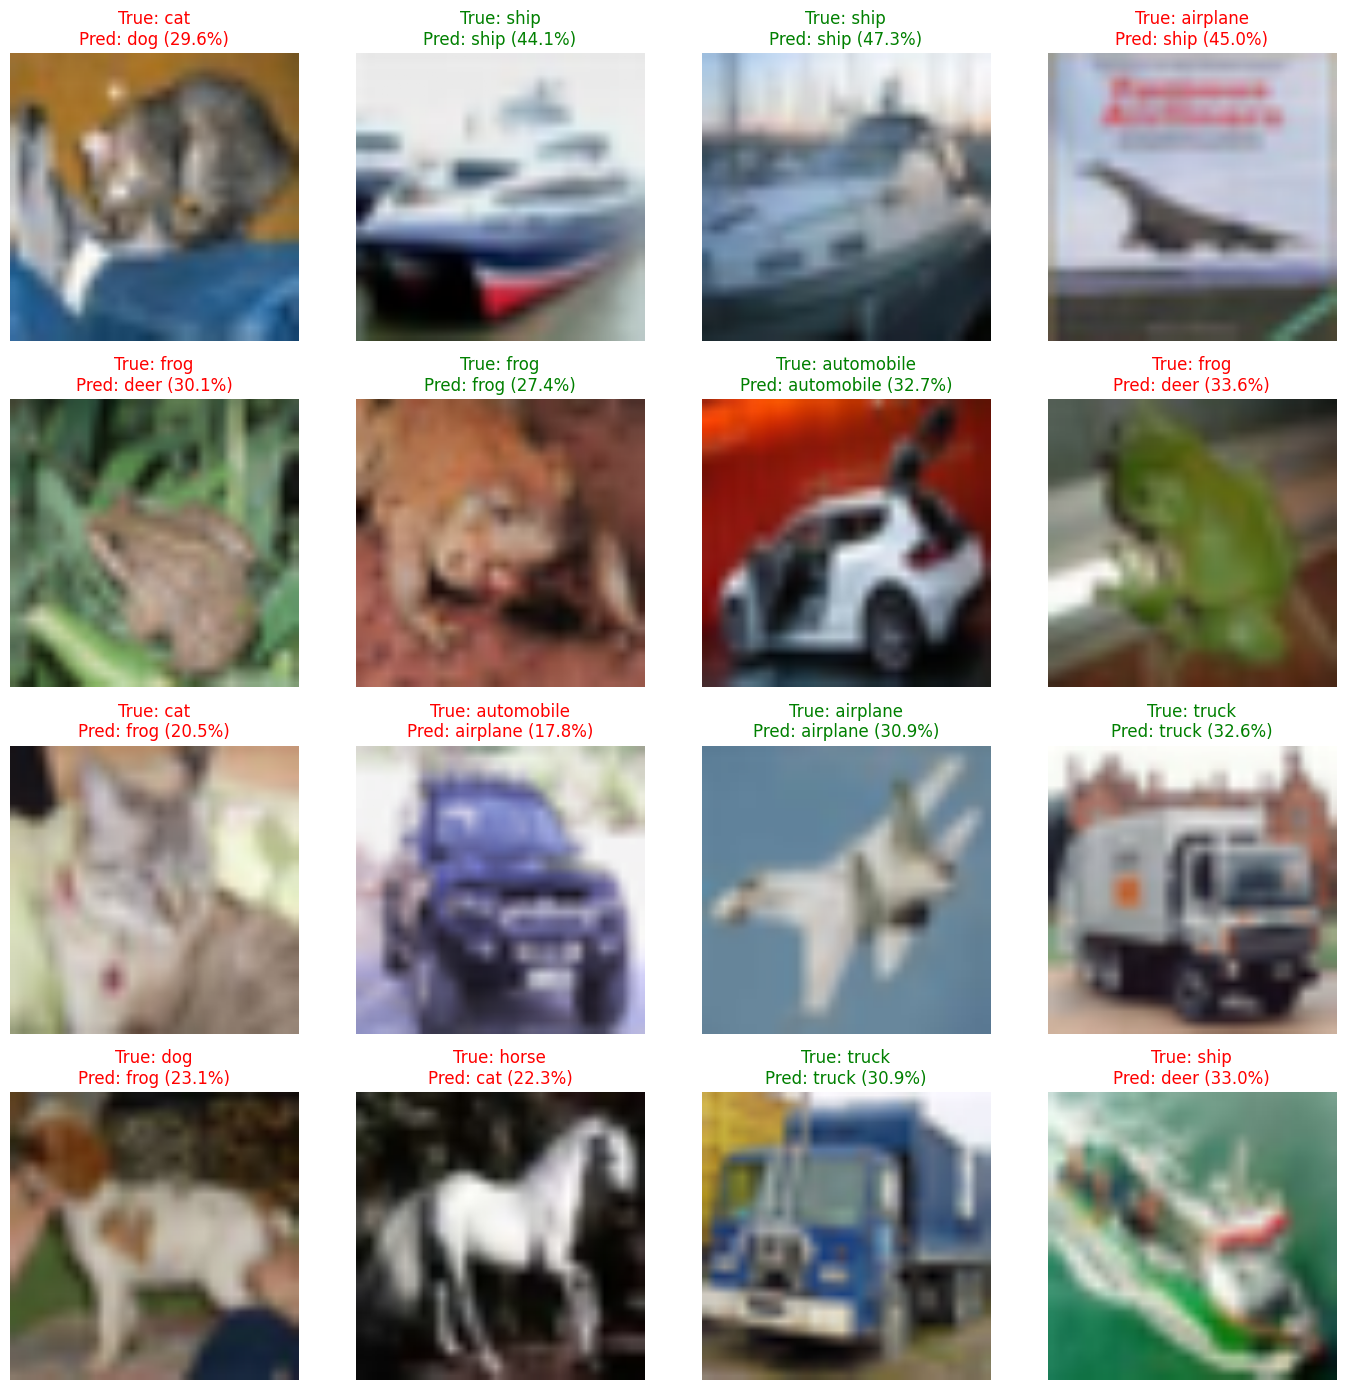

In [6]:
import matplotlib.pyplot as plt
import numpy as np

classes = train_full.classes

def deit_predict(x):
    patches = patch_embed(x).flatten(2).permute(0, 2, 1)
    B = patches.shape[0]

    X = torch.cat((
        cls_token.expand(B, -1, -1),
        dist_token.expand(B, -1, -1),
        patches
    ), dim=1) + pos_embed

    B, G, _ = X.shape

    normed = ln1(X)

    Q = w_q(normed).reshape(B, G, n_heads, d_head).transpose(1, 2)
    K = w_k(normed).reshape(B, G, n_heads, d_head).transpose(1, 2)
    V = w_v(normed).reshape(B, G, n_heads, d_head).transpose(1, 2)

    attn_wts = F.softmax(
        Q @ K.transpose(-2, -1) / (d_head ** 0.5),
        dim=-1
    )

    context = (
        attn_wts @ V
    ).transpose(1, 2).contiguous().reshape(B, G, embed_dim)

    X = X + w_o(context)
    X = X + mlp(ln_pre_mlp(X))

    out = final_ln(X)

    cls_logits = cls_head(out[:, 0])
    dist_logits = dist_head(out[:, 1])

    probs = (
        cls_logits.softmax(-1) +
        dist_logits.softmax(-1)
    ) / 2

    confidence, predictions = probs.max(-1)

    return predictions, confidence, probs


def denormalize(x):
    mean = torch.tensor([0.485, 0.456, 0.406], device=x.device).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=x.device).view(3, 1, 1)
    return x * std + mean


patch_embed.eval()
ln1.eval()
w_q.eval()
w_k.eval()
w_v.eval()
w_o.eval()
ln_pre_mlp.eval()
mlp.eval()
final_ln.eval()
cls_head.eval()
dist_head.eval()

images, labels = next(iter(test_dl))
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    predictions, confidence, probs = deit_predict(images)

fig, axes = plt.subplots(4, 4, figsize=(14, 14))

for i, ax in enumerate(axes.flat):
    image = denormalize(images[i]).clamp(0, 1)
    image = image.permute(1, 2, 0).cpu().numpy()

    ax.imshow(image)

    true_name = classes[labels[i].item()]
    pred_name = classes[predictions[i].item()]
    conf = confidence[i].item()

    ax.set_title(
        f"True: {true_name}\nPred: {pred_name} ({conf:.1%})",
        color="green" if predictions[i] == labels[i] else "red"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

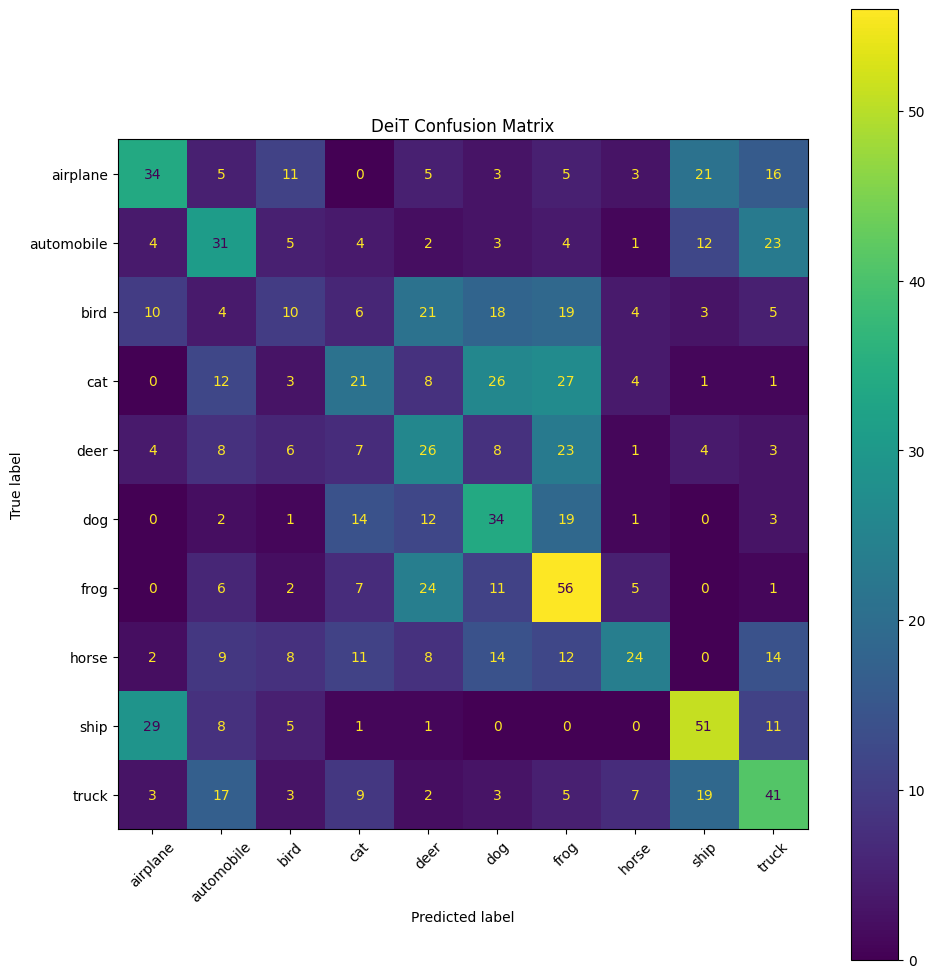

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds = []
all_labels = []

with torch.no_grad():
    for xb, yb in test_dl:
        xb = xb.to(device)

        preds, _, _ = deit_predict(xb)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.numpy())

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(10, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(ax=ax, xticks_rotation=45)

plt.title("DeiT Confusion Matrix")
plt.tight_layout()
plt.show()

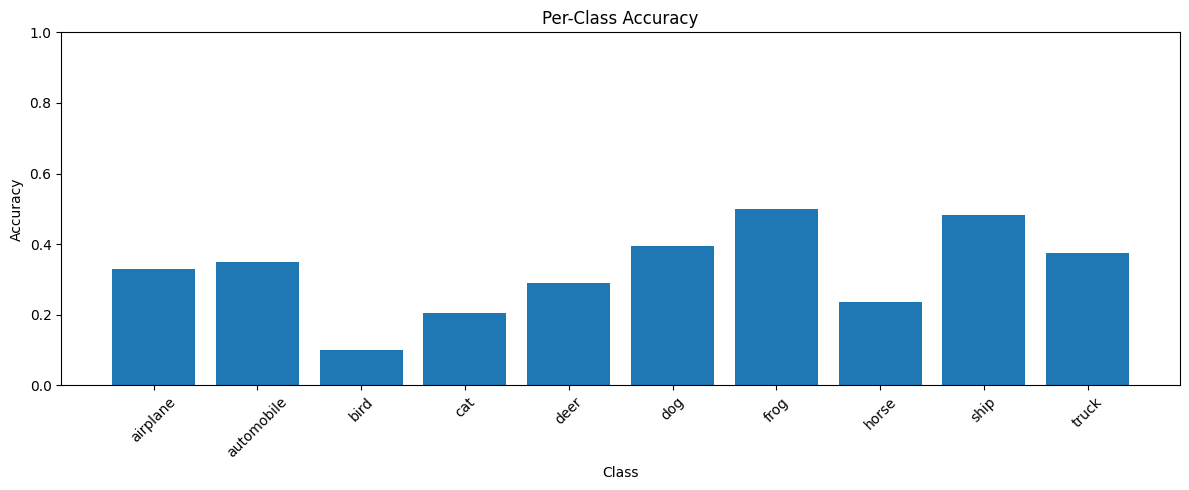

In [8]:
class_correct = np.zeros(num_classes)
class_total = np.zeros(num_classes)

for label, pred in zip(all_labels, all_preds):
    class_total[label] += 1
    class_correct[label] += int(label == pred)

class_acc = class_correct / class_total

plt.figure(figsize=(12, 5))

plt.bar(classes, class_acc)

plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.xlabel("Class")
plt.title("Per-Class Accuracy")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [9]:
model_state = {
    "patch_embed": patch_embed.state_dict(),
    "cls_param": cls_token.detach().cpu(),
    "dist_param": dist_token.detach().cpu(),
    "pos_embed": pos_embed.detach().cpu(),
    "ln1": ln1.state_dict(),
    "w_q": w_q.state_dict(),
    "w_k": w_k.state_dict(),
    "w_v": w_v.state_dict(),
    "w_o": w_o.state_dict(),
    "ln_pre_mlp": ln_pre_mlp.state_dict(),
    "mlp": mlp.state_dict(),
    "final_ln": final_ln.state_dict(),
    "cls_head": cls_head.state_dict(),
    "dist_head": dist_head.state_dict(),
    "embed_dim": embed_dim,
    "n_heads": n_heads,
    "patch_size": patch_size,
    "num_classes": num_classes,
}

torch.save(model_state, "deit_cifar10.pth")

print("Saved: deit_cifar10.pth")

Saved: deit_cifar10.pth
